**Cell 1 — Install & Imports**

In [3]:
# Install required packages
# !pip install faiss-cpu sentence-transformers chromadb -q

import numpy as np
import torch
from sentence_transformers import SentenceTransformer
import faiss
import json
import re
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("All imports successful!")

All imports successful!


**Cell 2 — Build a Knowledge Base**

In [4]:
# Our "documents" — imagine these are your company docs,
# research papers, support tickets, etc.

documents = [
    # AI/ML topics
    "Transformers are neural networks that use attention mechanisms to process sequences. They were introduced in the paper 'Attention Is All You Need' by Vaswani et al. in 2017.",
    "BERT is a bidirectional encoder trained on masked language modelling. It can see both left and right context simultaneously, making it excellent for understanding tasks.",
    "GPT is a decoder-only model trained on next token prediction. It generates text autoregressively, one token at a time, seeing only previous tokens.",
    "LoRA stands for Low-Rank Adaptation. It freezes the original model weights and adds small trainable matrices A and B. Only these matrices are updated during fine-tuning.",
    "RAG stands for Retrieval Augmented Generation. It retrieves relevant documents at inference time and uses them as context for the LLM to generate grounded answers.",
    "Fine-tuning adapts a pre-trained model to a specific task by continuing training on task-specific data. It preserves general knowledge while learning task-specific patterns.",
    "Attention mechanisms compute relevance scores between all pairs of tokens in a sequence. Each token attends to all others weighted by relevance.",
    "Embeddings are dense vector representations of text where semantically similar texts have similar vectors. They enable semantic search and similarity comparison.",
    "Perplexity measures how well a language model predicts text. Lower perplexity means the model is more confident. It equals exp(cross-entropy loss).",
    "Causal masking prevents tokens from attending to future positions. It enforces left-to-right generation in decoder-only models like GPT.",
    
    # Python/PyTorch topics
    "PyTorch is an open-source deep learning framework. It uses dynamic computation graphs and is widely used for research and production.",
    "The training loop in PyTorch follows: zero gradients, forward pass, compute loss, backward pass, update parameters.",
    "DataLoader in PyTorch handles batching, shuffling, and parallel data loading. It wraps a Dataset object.",
    "Adam optimizer adapts learning rates for each parameter. AdamW adds weight decay for regularisation.",
    
    # NLP topics
    "TF-IDF weights words by how often they appear in a document versus across all documents. Rare words get higher weights.",
    "Word2Vec trains on predicting context words from target words. Similar words end up with similar vector representations.",
    "Tokenisation converts raw text into tokens. BPE (Byte Pair Encoding) is the most common subword tokenisation method.",
    "Stemming reduces words to their root form. Lemmatisation maps words to their dictionary form. Both reduce vocabulary size.",
]

print(f"Knowledge base: {len(documents)} documents")
print(f"\nSample documents:")
for i, doc in enumerate(documents[:3]):
    print(f"  {i+1}. {doc[:100]}...")

Knowledge base: 18 documents

Sample documents:
  1. Transformers are neural networks that use attention mechanisms to process sequences. They were intro...
  2. BERT is a bidirectional encoder trained on masked language modelling. It can see both left and right...
  3. GPT is a decoder-only model trained on next token prediction. It generates text autoregressively, on...


**Cell 3 — Embed Documents (Indexing Step)**

In [5]:
print("="*70)
print("STEP 1: INDEXING — Embed all documents")
print("="*70)

# Load a pre-trained sentence embedding model
# This converts text → dense vectors
print("\nLoading embedding model...")
embedder = SentenceTransformer('all-MiniLM-L6-v2')
# Small but powerful: 384-dimensional embeddings
# Trained specifically for semantic similarity

print("Embedding documents...")
doc_embeddings = embedder.encode(documents, show_progress_bar=True)

print(f"\nEmbedding shape: {doc_embeddings.shape}")
print(f"  {len(documents)} documents")
print(f"  {doc_embeddings.shape[1]} dimensions per embedding")

# Visualise embedding norms
norms = np.linalg.norm(doc_embeddings, axis=1)
print(f"\nEmbedding statistics:")
print(f"  Mean norm: {norms.mean():.3f}")
print(f"  Std norm:  {norms.std():.3f}")
print(f"  (Normalised embeddings have norm=1)")

STEP 1: INDEXING — Embed all documents

Loading embedding model...
Embedding documents...


Batches: 100%|██████████| 1/1 [00:01<00:00,  1.34s/it]


Embedding shape: (18, 384)
  18 documents
  384 dimensions per embedding

Embedding statistics:
  Mean norm: 1.000
  Std norm:  0.000
  (Normalised embeddings have norm=1)


**Cell 4 — Build FAISS Vector Store**

In [6]:
print("="*70)
print("STEP 2: BUILD VECTOR STORE (FAISS)")
print("="*70)

# FAISS = Facebook AI Similarity Search
# Extremely fast similarity search over dense vectors

embedding_dim = doc_embeddings.shape[1]

# Create FAISS index
# IndexFlatIP = Inner Product (cosine similarity for normalised vectors)
index = faiss.IndexFlatIP(embedding_dim)

# Normalise embeddings (required for cosine similarity with IndexFlatIP)
doc_embeddings_norm = doc_embeddings / np.linalg.norm(
    doc_embeddings, axis=1, keepdims=True
)

# Add documents to index
index.add(doc_embeddings_norm.astype('float32'))

print(f"\nFAISS index built:")
print(f"  Index type: IndexFlatIP (cosine similarity)")
print(f"  Documents indexed: {index.ntotal}")
print(f"  Embedding dimension: {embedding_dim}")
print(f"\nVector store is ready for similarity search!")

STEP 2: BUILD VECTOR STORE (FAISS)

FAISS index built:
  Index type: IndexFlatIP (cosine similarity)
  Documents indexed: 18
  Embedding dimension: 384

Vector store is ready for similarity search!


**Cell 5 — Retrieval Function**

In [7]:
def retrieve(query, index, documents, embedder, top_k=3):
    """
    Retrieve most relevant documents for a query.
    
    Steps:
    1. Embed the query
    2. Find most similar document vectors
    3. Return top-k documents
    """
    
    # Step 1: Embed query
    query_embedding = embedder.encode([query])
    
    # Step 2: Normalise
    query_embedding_norm = query_embedding / np.linalg.norm(
        query_embedding, axis=1, keepdims=True
    )
    
    # Step 3: Search FAISS index
    similarities, indices = index.search(
        query_embedding_norm.astype('float32'), 
        top_k
    )
    
    # Step 4: Return results
    results = []
    for sim, idx in zip(similarities[0], indices[0]):
        results.append({
            'document': documents[idx],
            'similarity': float(sim),
            'index': int(idx)
        })
    
    return results

# Test retrieval
print("="*70)
print("STEP 3: RETRIEVAL — Find relevant documents")
print("="*70)

test_queries = [
    "How does attention work?",
    "What is LoRA?",
    "How do I train a model in PyTorch?",
]

for query in test_queries:
    print(f"\nQuery: '{query}'")
    results = retrieve(query, index, documents, embedder, top_k=2)
    for i, result in enumerate(results):
        print(f"  Result {i+1} (similarity: {result['similarity']:.3f}):")
        print(f"    {result['document'][:100]}...")

STEP 3: RETRIEVAL — Find relevant documents

Query: 'How does attention work?'
  Result 1 (similarity: 0.640):
    Attention mechanisms compute relevance scores between all pairs of tokens in a sequence. Each token ...
  Result 2 (similarity: 0.449):
    Transformers are neural networks that use attention mechanisms to process sequences. They were intro...

Query: 'What is LoRA?'
  Result 1 (similarity: 0.770):
    LoRA stands for Low-Rank Adaptation. It freezes the original model weights and adds small trainable ...
  Result 2 (similarity: 0.168):
    RAG stands for Retrieval Augmented Generation. It retrieves relevant documents at inference time and...

Query: 'How do I train a model in PyTorch?'
  Result 1 (similarity: 0.668):
    The training loop in PyTorch follows: zero gradients, forward pass, compute loss, backward pass, upd...
  Result 2 (similarity: 0.636):
    PyTorch is an open-source deep learning framework. It uses dynamic computation graphs and is widely ...


**Cell 6 — Simple RAG Pipeline (No LLM)**

In [8]:
def rag_pipeline_simple(query, index, documents, embedder, top_k=3):
    """
    Simple RAG pipeline:
    1. Retrieve relevant documents
    2. Build augmented prompt
    3. Return prompt (in production: feed to LLM)
    """
    
    # Step 1: Retrieve
    retrieved = retrieve(query, index, documents, embedder, top_k=top_k)
    
    # Step 2: Build context
    context = "\n\n".join([
        f"Document {i+1}: {r['document']}"
        for i, r in enumerate(retrieved)
    ])
    
    # Step 3: Build augmented prompt
    prompt = f"""Answer the question based on the following context.

Context:
{context}

Question: {query}

Answer:"""
    
    return prompt, retrieved

# Test the pipeline
print("="*70)
print("RAG PIPELINE DEMO")
print("="*70)

queries = [
    "What is the difference between BERT and GPT?",
    "How does LoRA reduce memory usage?",
    "What is perplexity in language models?",
]

for query in queries:
    print(f"\n{'='*60}")
    print(f"Query: {query}")
    print(f"{'='*60}")
    
    prompt, retrieved = rag_pipeline_simple(query, index, documents, embedder)
    
    print(f"\nRetrieved {len(retrieved)} documents:")
    for i, r in enumerate(retrieved):
        print(f"  {i+1}. (sim={r['similarity']:.3f}) {r['document'][:80]}...")
    
    print(f"\nAugmented prompt:")
    print(prompt[:400] + "...")

RAG PIPELINE DEMO

Query: What is the difference between BERT and GPT?

Retrieved 3 documents:
  1. (sim=0.605) GPT is a decoder-only model trained on next token prediction. It generates text ...
  2. (sim=0.496) BERT is a bidirectional encoder trained on masked language modelling. It can see...
  3. (sim=0.319) Causal masking prevents tokens from attending to future positions. It enforces l...

Augmented prompt:
Answer the question based on the following context.

Context:
Document 1: GPT is a decoder-only model trained on next token prediction. It generates text autoregressively, one token at a time, seeing only previous tokens.

Document 2: BERT is a bidirectional encoder trained on masked language modelling. It can see both left and right context simultaneously, making it excellent for understanding ta...

Query: How does LoRA reduce memory usage?

Retrieved 3 documents:
  1. (sim=0.620) LoRA stands for Low-Rank Adaptation. It freezes the original model weights and a...
  2. (sim=0

**Cell 7 — Visualise Similarity Search**

VISUALISING SIMILARITY SEARCH


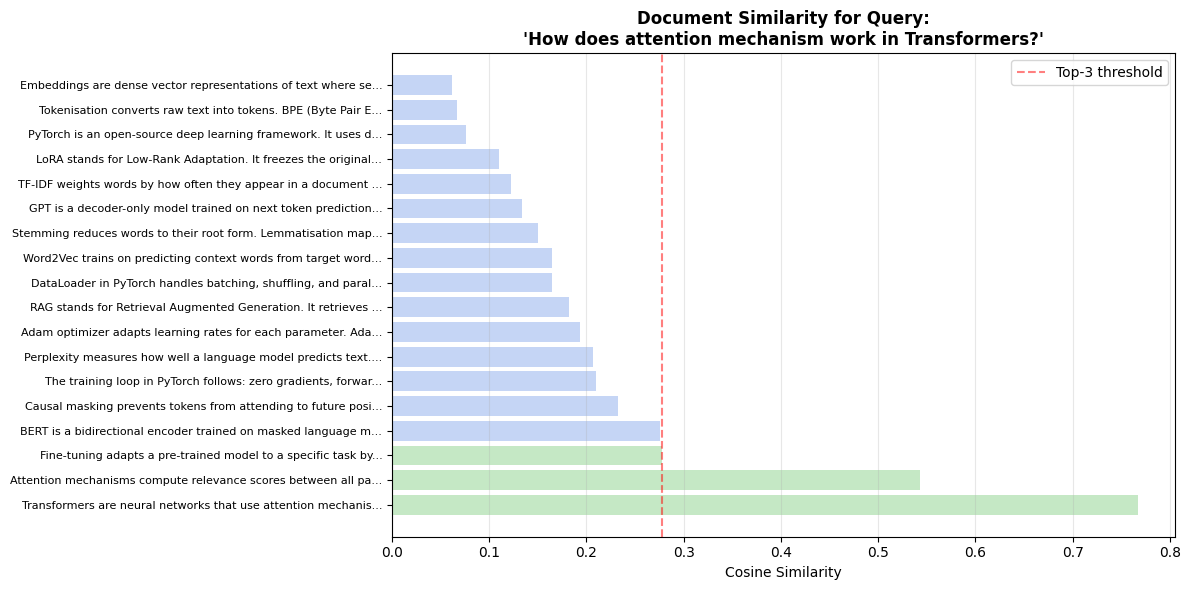


Top 3 most relevant documents:
  1. (sim=0.767) Transformers are neural networks that use attention mechanisms to process sequences. They were intro...
  2. (sim=0.543) Attention mechanisms compute relevance scores between all pairs of tokens in a sequence. Each token ...
  3. (sim=0.278) Fine-tuning adapts a pre-trained model to a specific task by continuing training on task-specific da...


In [9]:
# Visualise how similarity search works
print("="*70)
print("VISUALISING SIMILARITY SEARCH")
print("="*70)

# Pick a query and show similarity scores for all documents
query = "How does attention mechanism work in Transformers?"
query_embedding = embedder.encode([query])
query_embedding_norm = query_embedding / np.linalg.norm(query_embedding)

# Compute similarity with all documents
similarities = np.dot(doc_embeddings_norm, query_embedding_norm.T).flatten()

# Sort by similarity
sorted_indices = np.argsort(similarities)[::-1]

# Plot
fig, ax = plt.subplots(figsize=(12, 6))

colors = ['#c5d5f5' if i > 2 else '#c5e8c5' for i in range(len(documents))]
bars = ax.barh(
    range(len(documents)),
    similarities[sorted_indices],
    color=[colors[i] for i in range(len(documents))]
)

ax.set_yticks(range(len(documents)))
ax.set_yticklabels(
    [documents[i][:60] + "..." for i in sorted_indices],
    fontsize=8
)
ax.set_xlabel("Cosine Similarity")
ax.set_title(f"Document Similarity for Query:\n'{query}'", fontweight='bold')
ax.axvline(x=similarities[sorted_indices[2]], color='red', 
           linestyle='--', alpha=0.5, label='Top-3 threshold')
ax.legend()
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nTop 3 most relevant documents:")
for i in range(3):
    idx = sorted_indices[i]
    print(f"  {i+1}. (sim={similarities[idx]:.3f}) {documents[idx][:100]}...")

**Cell 8 — Full RAG with GPT-2**

In [10]:
# Full RAG pipeline using GPT-2 as the LLM
from transformers import GPT2Tokenizer, GPT2LMHeadModel

print("="*70)
print("FULL RAG PIPELINE WITH GPT-2")
print("="*70)

# Load GPT-2
print("\nLoading GPT-2...")
gpt2_tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
gpt2_model = GPT2LMHeadModel.from_pretrained('gpt2')
gpt2_tokenizer.pad_token = gpt2_tokenizer.eos_token
gpt2_model.eval()

def rag_with_gpt2(query, index, documents, embedder, 
                  gpt2_model, gpt2_tokenizer, top_k=2, max_new_tokens=80):
    """Full RAG: retrieve → augment → generate"""
    
    # Step 1: Retrieve relevant documents
    retrieved = retrieve(query, index, documents, embedder, top_k=top_k)
    
    # Step 2: Build context (keep short for GPT-2's context window)
    context = " ".join([r['document'] for r in retrieved])[:300]
    
    # Step 3: Build prompt
    prompt = f"Context: {context}\nQuestion: {query}\nAnswer:"
    
    # Step 4: Generate with GPT-2
    inputs = gpt2_tokenizer(
        prompt,
        return_tensors='pt',
        max_length=400,
        truncation=True
    )
    
    with torch.no_grad():
        outputs = gpt2_model.generate(
            inputs['input_ids'],
            max_new_tokens=max_new_tokens,
            temperature=0.7,
            top_p=0.9,
            do_sample=True,
            pad_token_id=gpt2_tokenizer.eos_token_id
        )
    
    # Decode only new tokens
    generated = gpt2_tokenizer.decode(
        outputs[0][inputs['input_ids'].shape[1]:],
        skip_special_tokens=True
    )
    
    return {
        'query': query,
        'retrieved': retrieved,
        'answer': generated.strip()
    }

# Test
queries = [
    "What is the difference between BERT and GPT?",
    "How does LoRA work?",
]

for query in queries:
    print(f"\nQuery: {query}")
    result = rag_with_gpt2(
        query, index, documents, embedder,
        gpt2_model, gpt2_tokenizer
    )
    
    print(f"\nRetrieved docs:")
    for r in result['retrieved']:
        print(f"  - (sim={r['similarity']:.3f}) {r['document'][:80]}...")
    
    print(f"\nGenerated answer:")
    print(f"  {result['answer']}")
    print("-" * 60)

FULL RAG PIPELINE WITH GPT-2

Loading GPT-2...


The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.



Query: What is the difference between BERT and GPT?

Retrieved docs:
  - (sim=0.605) GPT is a decoder-only model trained on next token prediction. It generates text ...
  - (sim=0.496) BERT is a bidirectional encoder trained on masked language modelling. It can see...

Generated answer:
  BERT is more accurate than GPT, because it can take into account the different context-specific features of the language model. In the case of BERT, the GPT model has the features of the GPT model, but not the features of the GPT model.
Question: What is the difference between GPT and BERT?
Answer: GPT is more accurate than B
------------------------------------------------------------

Query: How does LoRA work?

Retrieved docs:
  - (sim=0.724) LoRA stands for Low-Rank Adaptation. It freezes the original model weights and a...
  - (sim=0.162) RAG stands for Retrieval Augmented Generation. It retrieves relevant documents a...

Generated answer:
  LoRA is a lightweight, simple, and fast-learning algor

**Cell 9 — RAG vs No RAG Comparison**

In [11]:
print("="*70)
print("RAG vs NO RAG COMPARISON")
print("="*70)

def generate_without_rag(query, model, tokenizer, max_new_tokens=80):
    """Generate answer without RAG (pure LLM)"""
    
    prompt = f"Question: {query}\nAnswer:"
    inputs = tokenizer(prompt, return_tensors='pt')
    
    with torch.no_grad():
        outputs = model.generate(
            inputs['input_ids'],
            max_new_tokens=max_new_tokens,
            temperature=0.7,
            top_p=0.9,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id
        )
    
    generated = tokenizer.decode(
        outputs[0][inputs['input_ids'].shape[1]:],
        skip_special_tokens=True
    )
    return generated.strip()

# Compare
test_query = "What is LoRA and how does it reduce memory usage?"

print(f"\nQuery: {test_query}")

print(f"\n{'='*40}")
print("WITHOUT RAG (pure GPT-2):")
print("="*40)
answer_no_rag = generate_without_rag(
    test_query, gpt2_model, gpt2_tokenizer
)
print(answer_no_rag)

print(f"\n{'='*40}")
print("WITH RAG (GPT-2 + retrieved context):")
print("="*40)
result_rag = rag_with_gpt2(
    test_query, index, documents, embedder,
    gpt2_model, gpt2_tokenizer
)
print(f"Retrieved: {result_rag['retrieved'][0]['document'][:100]}...")
print(f"\nAnswer: {result_rag['answer']}")

RAG vs NO RAG COMPARISON

Query: What is LoRA and how does it reduce memory usage?

WITHOUT RAG (pure GPT-2):
LoRA is a method of computing the number of bytes in memory of a given data structure. The actual number of bytes is determined by a number function that is provided by the data structure. The function that is provided by the data structure is called a memory location.
In a memory location, a data structure contains the following types of data:
The initial data structure is a sequence of bytes which

WITH RAG (GPT-2 + retrieved context):
Retrieved: LoRA stands for Low-Rank Adaptation. It freezes the original model weights and adds small trainable ...

Answer: LoRA is a very efficient way to store data in PyTorch. It can be used to store data in Python as well as to store in a file system.
Question: What is the current state of the LoRA module?
Answer: LoRA is an experimental tool in PyTorch. It is very small and it has many limitations. Most of the features of LoRA are


**Cell 10 — Summary**

In [12]:
print("""
RAG PIPELINE — SUMMARY

What we built:
  1. Knowledge base (18 documents about NLP/ML)
  2. Embedding model (sentence-transformers MiniLM)
  3. FAISS vector store (cosine similarity search)
  4. Retrieval function (top-k similar documents)
  5. RAG pipeline (retrieve → augment → generate)
  6. Full RAG with GPT-2 as the LLM
  7. RAG vs No-RAG comparison

Three steps of RAG:
  INDEXING:   Documents → embeddings → vector store (one-time)
  RETRIEVAL:  Query → embedding → find similar docs → top-k
  GENERATION: Query + retrieved docs → prompt → LLM → answer

RAG vs Fine-tuning:
  Fine-tuning: bake knowledge into weights (expensive, static)
  RAG:         retrieve at inference time (cheap, dynamic)

When to use RAG:
  ✅ Knowledge changes frequently
  ✅ Large private knowledge base
  ✅ Need to cite sources
  ✅ Can't afford fine-tuning
  ✅ Want to reduce hallucination

When to use Fine-tuning:
  ✅ Style/tone adaptation
  ✅ Domain-specific reasoning
  ✅ Latency-sensitive (no retrieval step)
  ✅ Small, stable knowledge base

Production RAG stack:
  Embeddings: OpenAI ada-002 or sentence-transformers
  Vector store: Pinecone, Weaviate, or ChromaDB
  LLM: GPT-4, Claude, or fine-tuned LLaMA
  Framework: LangChain or LlamaIndex
""")


RAG PIPELINE — SUMMARY

What we built:
  1. Knowledge base (18 documents about NLP/ML)
  2. Embedding model (sentence-transformers MiniLM)
  3. FAISS vector store (cosine similarity search)
  4. Retrieval function (top-k similar documents)
  5. RAG pipeline (retrieve → augment → generate)
  6. Full RAG with GPT-2 as the LLM
  7. RAG vs No-RAG comparison

Three steps of RAG:
  INDEXING:   Documents → embeddings → vector store (one-time)
  RETRIEVAL:  Query → embedding → find similar docs → top-k
  GENERATION: Query + retrieved docs → prompt → LLM → answer

RAG vs Fine-tuning:
  Fine-tuning: bake knowledge into weights (expensive, static)
  RAG:         retrieve at inference time (cheap, dynamic)

When to use RAG:
  ✅ Knowledge changes frequently
  ✅ Large private knowledge base
  ✅ Need to cite sources
  ✅ Can't afford fine-tuning
  ✅ Want to reduce hallucination

When to use Fine-tuning:
  ✅ Style/tone adaptation
  ✅ Domain-specific reasoning
  ✅ Latency-sensitive (no retrieval step)
